In [1]:
from pathlib import Path
from timeit import default_timer as timer

import matplotlib.pyplot as plt
import numpy as np
from firedrake import *
from tqdm import tqdm

In [2]:
INDICATOR_TEST = "indicator_half"

P1_ROOT = Path("final/p1d1")
P2_ROOT = Path("final/p2d1")
CI_Z = 1.96


In [3]:
def _resolve_output_root(path: Path) -> Path:
    candidates = [path, Path("experimental_features") / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        f"Could not find {path!s}. Tried: "
        + ", ".join(str(candidate) for candidate in candidates)
    )


P1_ROOT = _resolve_output_root(P1_ROOT)
P2_ROOT = _resolve_output_root(P2_ROOT)
OUTPUT_ROOTS = {1: P1_ROOT, 2: P2_ROOT}
print(f"p=1 root: {P1_ROOT}")
print(f"p=2 root: {P2_ROOT}")

p=1 root: /home/kam/PhD/dG-DK-paper/experiments/final/p1d1
p=2 root: /home/kam/PhD/dG-DK-paper/experiments/final/p2d1


In [4]:
INDICATOR_TESTS = {
    "indicator_half": {
        "label": r"$1_{[\pi/2,3\pi/2]}$",
        "interval": (np.pi / 2, 3 * np.pi / 2),
        "exact_particle_moment": 0.07245614571389715,
        "mfl_phi": 0.5082485133637601,
        "alignment_mod": 4,
        "reference_slope": 1.0,
        "notes": "Jump endpoints are mesh nodes iff nx is divisible by 4.",
    },
}

print("Available indicator tests:")
for name, meta in INDICATOR_TESTS.items():
    print(f"  {name:22s} exact={meta['exact_particle_moment']:.16g}  {meta['label']}")

if INDICATOR_TEST not in INDICATOR_TESTS:
    raise KeyError(f"Unknown INDICATOR_TEST={INDICATOR_TEST!r}")

TEST_META = INDICATOR_TESTS[INDICATOR_TEST]
EXACT_PARTICLE_MOMENT = TEST_META["exact_particle_moment"]
print(f"\nSelected: {INDICATOR_TEST}")
print(f"Label: {TEST_META['label']}")
print(f"Exact particle moment: {EXACT_PARTICLE_MOMENT:.17g}")
print(f"MFL pairing: {TEST_META['mfl_phi']:.17g}")
print(TEST_META["notes"])

Available indicator tests:
  indicator_half         exact=0.07245614571389715  $1_{[\pi/2,3\pi/2]}$

Selected: indicator_half
Label: $1_{[\pi/2,3\pi/2]}$
Exact particle moment: 0.072456145713897149
MFL pairing: 0.50824851336376009
Jump endpoints are mesh nodes iff nx is divisible by 4.


In [5]:
def phi_expression(x):
    lo, hi = TEST_META["interval"]
    return conditional(And(x >= lo, x <= hi), 1.0, 0.0)

In [6]:
def parse_params_file(path: Path):
    params = {}
    for line in path.read_text().splitlines():
        if " = " not in line:
            continue
        key, value = line.split(" = ", 1)
        params[key.strip()] = value.strip()
    return params


def coerce_params(params):
    return {
        "experiment_id": params["experiment ID"],
        "nx": int(params["nx"]),
        "N": int(params["N"]),
        "total_runs": int(params["total runs"]),
        "eta": float(params["eta"]),
        "dt": float(params["dt"]),
        "T": float(params["T"]),
        "kappa": float(params["kappa"]),
        "degree": int(params["polynomial degree"]),
        "seed": int(params["SEED"]),
        "variant": params["variant"],
        "initial_condition_method": params["initial condition method"],
        "noise_gradient": params["noise gradient"],
        "procs": int(params["procs"]),
        "total_time": float(params["Total time"]),
    }


def load_sweep(root: Path):
    rows = []
    for folder in sorted(root.iterdir()):
        params_path = folder / "params.txt"
        if not folder.is_dir() or not params_path.exists():
            continue
        metadata = coerce_params(parse_params_file(params_path))
        metadata["folder"] = folder
        rows.append(metadata)
    if not rows:
        raise FileNotFoundError(f"No experiment folders with params.txt found in {root}")

    # If the same nx was run more than once, keep the latest timestamped folder.
    by_nx = {}
    for row in sorted(rows, key=lambda item: item["folder"].name):
        by_nx[row["nx"]] = row
    return by_nx


sweeps = {degree: load_sweep(root) for degree, root in OUTPUT_ROOTS.items()}
alignment_mod = TEST_META.get("alignment_mod")
if alignment_mod is None:
    raise ValueError("cost_comparison.ipynb is intended for mesh-aligned indicator tests with alignment_mod set.")

common_nxs_all = np.array(sorted(set(sweeps[1]) & set(sweeps[2])), dtype=int)
common_nxs = np.array([nx for nx in common_nxs_all if nx % alignment_mod == 0], dtype=int)
if common_nxs.size == 0:
    raise ValueError("No common mesh-aligned mesh sizes between p=1 and p=2 sweeps")

print(f"Using mesh-aligned common mesh sizes only: {common_nxs.tolist()}")

for degree, sweep in sweeps.items():
    print(f"p={degree}: {len(sweep)} mesh sizes from {OUTPUT_ROOTS[degree].name}")
    for nx in common_nxs:
        row = sweep[int(nx)]
        print(
            f"  nx={nx:3d} M={row['total_runs']} dt={row['dt']} T={row['T']} "
            f"time={row['total_time']:.1f}s folder={row['folder'].name}"
        )

# Check that the simulation budget really matches in the intended sense.
for field in ["N", "total_runs", "dt", "T", "kappa", "noise_gradient", "variant", "initial_condition_method", "procs"]:
    values = {sweeps[degree][int(nx)][field] for degree in sweeps for nx in common_nxs}
    print(f"{field}: {sorted(values)}")

Using mesh-aligned common mesh sizes only: [4, 8, 12]
p=1: 6 mesh sizes from p1d1
  nx=  4 M=60000 dt=0.001 T=0.1 time=1521.1s folder=20260722T171209399976_p1_nx004_N500000_dt0.001_T0.1_kappa1_eta10_equispaced_mfl-first_full_seed123_M60000_workers5
  nx=  8 M=60000 dt=0.001 T=0.1 time=1565.6s folder=20260722T180211654527_p1_nx008_N500000_dt0.001_T0.1_kappa1_eta10_equispaced_mfl-first_full_seed123_M60000_workers5
  nx= 12 M=60000 dt=0.001 T=0.1 time=1615.5s folder=20260722T185257292948_p1_nx012_N500000_dt0.001_T0.1_kappa1_eta10_equispaced_mfl-first_full_seed123_M60000_workers5
p=2: 6 mesh sizes from p2d1
  nx=  4 M=60000 dt=0.001 T=0.1 time=1604.0s folder=20260722T202244236194_p2_nx004_N500000_dt0.001_T0.1_kappa1_eta10_equispaced_mfl-first_full_seed123_M60000_workers5
  nx=  8 M=60000 dt=0.001 T=0.1 time=1653.0s folder=20260722T211503316424_p2_nx008_N500000_dt0.001_T0.1_kappa1_eta10_equispaced_mfl-first_full_seed123_M60000_workers5
  nx= 12 M=60000 dt=0.001 T=0.1 time=1663.8s folder=202

In [7]:
def first_matching_file(folder: Path, pattern: str):
    matches = sorted(folder.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No files matching {pattern!r} in {folder}")
    return matches[0]


def compute_indicator_samples(metadata):
    nx = metadata["nx"]
    degree = metadata["degree"]
    N = metadata["N"]
    noise_gradient = metadata["noise_gradient"]
    folder = metadata["folder"]

    mesh = PeriodicIntervalMesh(ncells=nx, length=2 * np.pi)
    DG = FunctionSpace(mesh, "DG", degree)
    v = TestFunction(DG)
    x, = SpatialCoordinate(mesh)

    phi_interp = Function(DG).interpolate(phi_expression(x))
    weights = assemble(phi_interp * v * dx).dat.data_ro.copy()

    mfl_path = first_matching_file(
        folder,
        f"worker*_mfl_p{degree}_nx{nx:03d}_noise-{noise_gradient}.npy",
    )
    mfl = np.load(mfl_path)

    rho_paths = sorted(folder.glob(f"worker*_dk_p{degree}_nx{nx:03d}_noise-{noise_gradient}.npz"))
    if not rho_paths:
        raise FileNotFoundError(f"No DK worker files found in {folder}")

    samples = []
    for rho_path in rho_paths:
        with np.load(rho_path) as rhos:
            keys = [key for key in rhos.files if key != "allow_pickle"]
            for key in tqdm(keys, desc=f"p={degree} nx={nx} {rho_path.name}", leave=False):
                rho = rhos[key]
                l2_inner = np.dot(mfl - rho, weights)
                samples.append((np.sqrt(N) * l2_inner) ** 2)

    return np.asarray(samples, dtype=float)


sample_data = {}
for degree in [1, 2]:
    sample_data[degree] = {}
    for nx in common_nxs:
        nx = int(nx)
        t0 = timer()
        sample_data[degree][nx] = compute_indicator_samples(sweeps[degree][nx])
        t1 = timer()
        print(f"p={degree} nx={nx:3d}: loaded {sample_data[degree][nx].size} samples in {t1 - t0:.2f}s")

/home/kam/firedrake/lib/python3.10/site-packages/pytools/persistent_dict.py:597: CollisionWarning: loopy-code-gen-cache-v3-2024.1-islpy2023.2.5-cgen2020.1-v1: key collision in cache at '/home/kam/.cache/pytools' -- these are sufficiently unlikely that they're often indicative of a broken hash key implementation (that is not considering some elements relevant for equality comparison)
  return self.fetch(key)
/home/kam/firedrake/lib/python3.10/site-packages/pytools/persistent_dict.py:597: CollisionWarning: loopy-memoize-cache-preprocess_program-LoopyKeyBuilder.LoopyKeyBuilder-v0-2024.1-islpy2023.2.5-cgen2020.1-v1: key collision in cache at '/home/kam/.cache/pytools' -- these are sufficiently unlikely that they're often indicative of a broken hash key implementation (that is not considering some elements relevant for equality comparison)
  return self.fetch(key)
/home/kam/firedrake/lib/python3.10/site-packages/pytools/persistent_dict.py:597: CollisionWarning: loopy-schedule-cache-v4-2024.

p=1 nx=  4: loaded 60000 samples in 18.80s


p=1 nx=  8: loaded 60000 samples in 15.72s


p=1 nx= 12: loaded 60000 samples in 16.54s


p=2 nx=  4: loaded 60000 samples in 16.67s


p=2 nx=  8: loaded 60000 samples in 16.55s


p=2 nx= 12: loaded 60000 samples in 16.45s


In [8]:
def summarise_samples(degree, nx, samples):
    metadata = sweeps[degree][nx]
    mean = float(np.mean(samples))
    std = float(np.std(samples, ddof=1))
    se = std / np.sqrt(samples.size)
    signed = mean - EXACT_PARTICLE_MOMENT
    weak = abs(signed)
    ci95 = CI_Z * se
    nsteps = int(round(metadata["T"] / metadata["dt"]))
    dofs = metadata["nx"] * (degree + 1)
    work_proxy = metadata["total_runs"] * nsteps * dofs
    alignment_mod = TEST_META.get("alignment_mod")

    return {
        "degree": degree,
        "nx": nx,
        "h": float(2 * np.pi / nx),
        "dofs": int(dofs),
        "nsteps": int(nsteps),
        "work_proxy": float(work_proxy),
        "wall_time": metadata["total_time"],
        "M": int(samples.size),
        "mean": mean,
        "std": std,
        "se": se,
        "ci95_halfwidth": ci95,
        "signed_difference": signed,
        "weak_error_abs": weak,
        "relative_ci95_halfwidth": np.inf if weak == 0.0 else ci95 / weak,
        "signed_ci95_contains_zero": bool(signed - ci95 <= 0.0 <= signed + ci95),
        "aligned": None if alignment_mod is None else bool(nx % alignment_mod == 0),
    }


if TEST_META.get("alignment_mod") is None:
    raise ValueError("cost_comparison.ipynb is intended for mesh-aligned indicator tests with alignment_mod set.")

rows = []
for degree in [1, 2]:
    for nx in common_nxs:
        row = summarise_samples(degree, int(nx), sample_data[degree][int(nx)])
        if row["aligned"] is True:
            rows.append(row)

if not rows:
    raise ValueError("No mesh-aligned results found for the selected indicator test.")

print("Using mesh-aligned results only.")
for row in rows:
    print(
        f"p={row['degree']} nx={row['nx']:3d} dofs={row['dofs']:3d} "
        f"weak={row['weak_error_abs']:.4e} se={row['se']:.2e} "
        f"95%half/weak={row['relative_ci95_halfwidth']:.2f} "
        f"zero_in_CI={row['signed_ci95_contains_zero']} aligned={row['aligned']}"
    )


Using mesh-aligned results only.
p=1 nx=  4 dofs=  8 weak=3.9906e-02 se=1.88e-04 95%half/weak=0.01 zero_in_CI=False aligned=True
p=1 nx=  8 dofs= 16 weak=2.8629e-02 se=2.54e-04 95%half/weak=0.02 zero_in_CI=False aligned=True
p=1 nx= 12 dofs= 24 weak=2.0297e-02 se=3.02e-04 95%half/weak=0.03 zero_in_CI=False aligned=True
p=2 nx=  4 dofs= 12 weak=2.3321e-02 se=2.85e-04 95%half/weak=0.02 zero_in_CI=False aligned=True
p=2 nx=  8 dofs= 24 weak=1.3654e-02 se=3.42e-04 95%half/weak=0.05 zero_in_CI=False aligned=True
p=2 nx= 12 dofs= 36 weak=9.0013e-03 se=3.67e-04 95%half/weak=0.08 zero_in_CI=False aligned=True


In [13]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "mathtext.fontset": "cm",
        "text.latex.preamble": r"\usepackage{amsmath,amssymb}",
    }
)

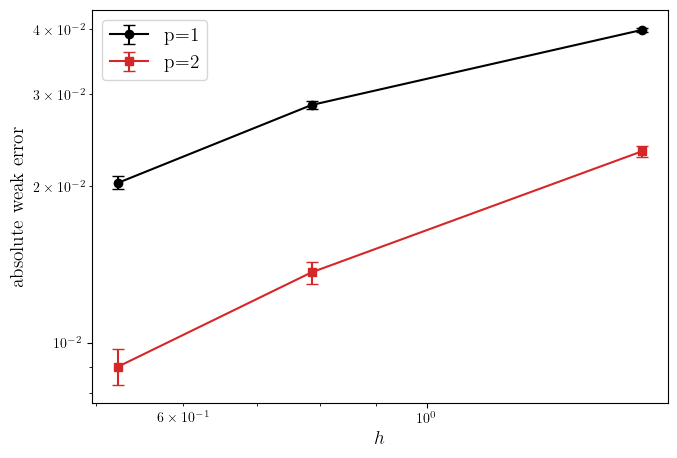

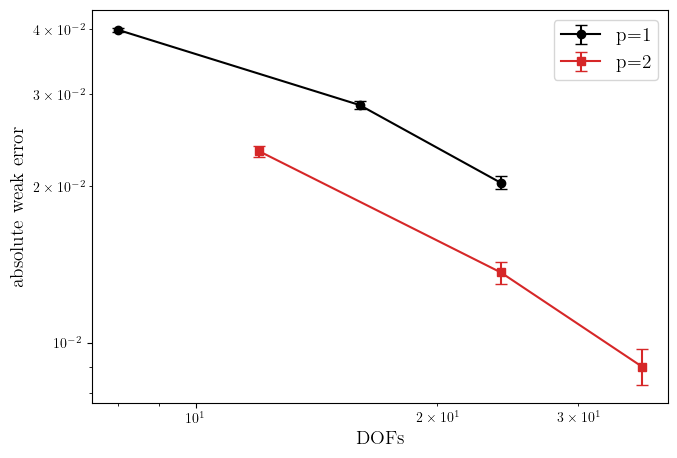

In [17]:
def rows_for_degree(degree):
    return sorted([row for row in rows if row["degree"] == degree], key=lambda row: row["h"])


def errorbar_arrays(rows_subset, x_key):
    x = np.asarray([row[x_key] for row in rows_subset], dtype=float)
    y = np.asarray([row["weak_error_abs"] for row in rows_subset], dtype=float)
    err = np.asarray([row["ci95_halfwidth"] for row in rows_subset], dtype=float)
    positive = y[y > 0]
    y_floor = max(np.min(positive) * 0.05, 1e-16) if positive.size else 1e-16
    lower = np.minimum(err, np.maximum(y - y_floor, 0.0))
    upper = err
    return x, y, np.vstack([lower, upper])


def plot_error_vs(x_key, xlabel, filename, *, logx=True):
    fig, ax = plt.subplots(figsize=(7.0, 4.8))
    styles = {
        1: {"marker": "o", "color": "black", "label": "p=1"},
        2: {"marker": "s", "color": "tab:red", "label": "p=2"},
    }
    for degree in [1, 2]:
        subset = rows_for_degree(degree)
        if not subset:
            continue
        x, y, yerr = errorbar_arrays(subset, x_key)
        order = np.argsort(x)
        x = x[order]
        y = y[order]
        yerr = yerr[:, order]
        ax.errorbar(x, y, yerr=yerr, capsize=4, linestyle="-", **styles[degree])

    if logx:
        ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("absolute weak error")
    ax.legend()
    fig.tight_layout()
    plt.show()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close(fig)


plot_error_vs("h", r"$h$", "weak_error_vs_h.pdf")
plot_error_vs("dofs", "DOFs", "weak_error_vs_dofs.pdf")
